In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/resulcaliskan/diamonds/diamonds.csv


# Diamond Price Prediction - Data Analysis

---

### 1. Importing Libraries and Loading Data
In this step, we are importing essential Python libraries like `numpy` for math operations and `pandas` for handling our data. We also search the Kaggle input directory to find our dataset file pathway.

---

### 2. Hiding Warnings
We use the `warnings` library and environment settings to hide unnecessary warnings. This keeps our notebook clean and easy to read.

---

### 3. Loading and Viewing the Dataset
Here, we read our dataset CSV file using `pd.read_csv()` and store it in a variable called `df`. We then use `df.head()` to look at the first 5 rows of our data to understand what it looks like.

---

### 4. Checking Data Shape
We use `df.shape` to see the total size of our dataset. The output shows us the total number of rows (data samples) and columns (features) in our file.

---

### 5. Checking for Missing (Null) Values
We use `df.isnull().sum()` to check if there are any missing or empty values in our dataset. Thankfully, every column shows 0, which means our data is clean and has no missing values.

---

### 6. Getting Data Information
We use `df.info()` to get a quick summary of our dataset. This shows us the data types of each column (like numbers or text) and confirms how much memory the data is using.


In [2]:
import warnings
import os

# Suppress standard Python warnings
warnings.filterwarnings('ignore')

# Suppress specialized library warnings (like LightGBM and XGBoost)
os.environ['PYTHONWARNINGS'] = 'ignore'


In [3]:
df=pd.read_csv("/kaggle/input/datasets/resulcaliskan/diamonds/diamonds.csv")
df.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335


In [4]:
df.shape

(53940, 10)

In [5]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
price      0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   x        53940 non-null  float64
 7   y        53940 non-null  float64
 8   z        53940 non-null  float64
 9   price    53940 non-null  int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


### 7. Statistical Summary of Data
We use `df.describe()` to get a quick statistical summary of our numerical data. It shows us important details like the average (mean), minimum, maximum, and standard deviation for each column.

---

### 8. Displaying the Dataset
By simply typing `df`, we can view both the beginning and the end of our dataset to double-check our rows and columns.

---

In [7]:
df.describe()

,carat,depth,table,x,y,z,price
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,5.731157,5.734526,3.538734,3932.799722
std,0.474011,1.432621,2.234491,1.121761,1.142135,0.705699,3989.439738
min,0.200000,43.000000,43.000000,0.000000,0.000000,0.000000,326.000000
25%,0.400000,61.000000,56.000000,4.710000,4.720000,2.910000,950.000000
50%,0.700000,61.800000,57.000000,5.700000,5.710000,3.530000,2401.000000
75%,1.040000,62.500000,59.000000,6.540000,6.540000,4.040000,5324.250000
max,5.010000,79.000000,95.000000,10.740000,58.900000,31.800000,18823.000000


In [8]:
df

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,5.75,5.76,3.50,2757
53936,0.72,Good,D,SI1,63.1,55.0,5.69,5.75,3.61,2757
53937,0.70,Very Good,D,SI1,62.8,60.0,5.66,5.68,3.56,2757
53938,0.86,Premium,H,SI2,61.0,58.0,6.15,6.12,3.74,2757


### 9. Importing Machine Learning Libraries
In this step, we import the tools we need to build our predictive models. We bring in advanced regression models (`XGBRegressor`, `CatBoostRegressor`, `LGBMRegressor`) and helper tools from `sklearn` to scale our data, handle text categories, and split our dataset.

---

### 10. Data Splitting and Feature Selection
Here, we separate our columns into text features (`oe_cols`) and numerical features (`std_scale_col`). We then split our data into features ($X$) and the target variable we want to predict ($y$, which is the price). Finally, we use `train_test_split` to divide our data into a training set ($80\%$) and a testing set ($20\%$).

---

### 11. Creating the Data Preprocessing Pipeline
We set up a pipeline to automatically clean and prepare our data. This pipeline will use `StandardScaler` to scale our numerical values so they are on the same level, and `OrdinalEncoder` to convert our text categories into numbers that our machine learning models can understand.

---

### 12. Hyperparameter Tuning Setup
In this cell, we initialize our three models and set up a parameter grid for tuning. We use `RandomizedSearchCV` to help us find the best settings (like the number of trees and learning rate) so our models can predict diamond prices as accurately as possible.


In [9]:
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.model_selection import train_test_split

In [10]:
oe_cols=["cut","color","clarity"]
std_scale_col=["carat","depth","table","x","y","z"]
X=df.drop("price",axis=1)
y=df["price"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)



In [11]:
pipe_std_scalar=Pipeline(steps=[("Scalar_Mode", StandardScaler())])
pipe_oe=Pipeline(steps=[("OrdinalEncoding",OrdinalEncoder())])
preprocessor=ColumnTransformer(transformers=[("Standardization",pipe_std_scalar,std_scale_col),
                                            ("Encoding",pipe_oe,oe_cols)])

### 13. Training and Tuning Multiple Models
In this cell, we run a loop to train and tune our three machine learning models: **XGBoost**, **LightGBM**, and **CatBoost**. 

Here is exactly what this code does in simple steps:
* **Defines Parameter Spaces:** We create lists of different settings (like tree depth and learning rates) for each model to try out.
* **Runs Randomized Search:** We use `RandomizedSearchCV` with 3-fold cross-validation to quickly test different combinations of these settings on our training data.
* **Evaluates Using RMSE:** The code measures performance using Root Mean Squared Error (RMSE) to see how far off our predictions are from the real prices (lower error is better).
* **Finds the Winner:** It tracks the scores and automatically saves the best-performing model setup as the absolute winner.
* 

In [12]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
# 1. Initialize the models with basic constraints for diamond data
xgb = XGBRegressor(random_state=42, objective='reg:squarederror')
lgb = LGBMRegressor(random_state=42, verbose=-1)
cat = CatBoostRegressor(random_state=42, verbose=0)

# 2. Set up diamond-optimized parameter spaces
# We look at depth and learning rates to capture exponential carat pricing safely.
xgb_params = {
    'regressor__n_estimators': [100, 300, 500],
    'regressor__max_depth': [4, 6, 8],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__subsample': [0.8, 1.0]
}

lgb_params = {
    'regressor__n_estimators': [100, 300, 500],
    'regressor__max_depth': [4, 6, 8],
    'regressor__num_leaves': [15, 31, 63],
    'regressor__learning_rate': [0.01, 0.05, 0.1]
}

cat_params = {
    'regressor__iterations': [100, 300, 500],
    'regressor__depth': [4, 6, 8],
    'regressor__learning_rate': [0.01, 0.05, 0.1]
}

# Group them for the loop
experiments = [
    ('XGBoost', xgb, xgb_params),
    ('LightGBM', lgb, lgb_params),
    ('CatBoost', cat, cat_params)
]

best_score = float('inf')
best_pipeline = None
winner_name = ""

# 3. Loop, Tune, and Evaluate
for name, model, params in experiments:
    print(f"⚡ Tuning {name}...")
    
    # Create the search pipeline using your existing preprocessor
    tuning_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Run a randomized search to find the best hyperparameters quickly
    search = RandomizedSearchCV(
        estimator=tuning_pipeline,
        param_distributions=params,
        n_iter=10,             # Adjust this based on your time constraints
        cv=3,                  # 3-fold cross validation
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=-1
    )
    
    search.fit(X_train, y_train)
    
    current_rmse = -search.best_score_
    print(f"👉 Best {name} RMSE: ${current_rmse:.2f}")
    print(f"👉 Best Params: {search.best_params_}\n")
    
   # Keep track of the absolute winner
    if current_rmse < best_score:
        best_score = current_rmse
        best_pipeline = search.best_estimator_
        winner_name = name

print(f"🏆 WINNER: {winner_name} with an RMSE of ${best_score:.2f}!")

⚡ Tuning XGBoost...
👉 Best XGBoost RMSE: $549.63
👉 Best Params: {'regressor__subsample': 0.8, 'regressor__n_estimators': 300, 'regressor__max_depth': 8, 'regressor__learning_rate': 0.05}

⚡ Tuning LightGBM...
👉 Best LightGBM RMSE: $548.69
👉 Best Params: {'regressor__num_leaves': 31, 'regressor__n_estimators': 500, 'regressor__max_depth': 6, 'regressor__learning_rate': 0.1}

⚡ Tuning CatBoost...
👉 Best CatBoost RMSE: $540.14
👉 Best Params: {'regressor__learning_rate': 0.1, 'regressor__iterations': 500, 'regressor__depth': 6}

🏆 WINNER: CatBoost with an RMSE of $540.14!


### 14. Model Evaluation on Test Data
Now that we have chosen our best pipeline, it is time to test it on unseen data to see how well it actually performs. 
* We use `best_pipeline.predict(X_test)` to generate diamond price predictions for our test dataset.
* We then calculate the **Root Mean Squared Error (RMSE)** to see how many dollars off our predictions generally are.
* We also calculate the **R² Score (R-squared)**, which tells us the percentage of variance in diamond prices that our model can successfully explain.

---

### 15. Feature Importance Visualization
In this final step, we want to look inside our winning machine learning model to see which diamond features matter the most when deciding a price.
* We extract the feature names and match them with their importance scores calculated by the model.
* We clean up the labels so they look neat and tidy.
* Finally, we use `matplotlib` to plot a horizontal bar chart showing the **Top Features Driving Diamond Price**. This makes it easy to visually see whether things like carat size, cut, or clarity affect the price the most.
* 

In [13]:
from sklearn.metrics import root_mean_squared_error, r2_score

# 1. Make predictions on the unseen test data
y_pred = best_pipeline.predict(X_test)

# 2. Calculate performance metrics
test_rmse = root_mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

print(f"Final Test RMSE: ${test_rmse:.2f}")
print(f"Final Test R² Score: {test_r2:.4f}")


Final Test RMSE: $526.95
Final Test R² Score: 0.9825


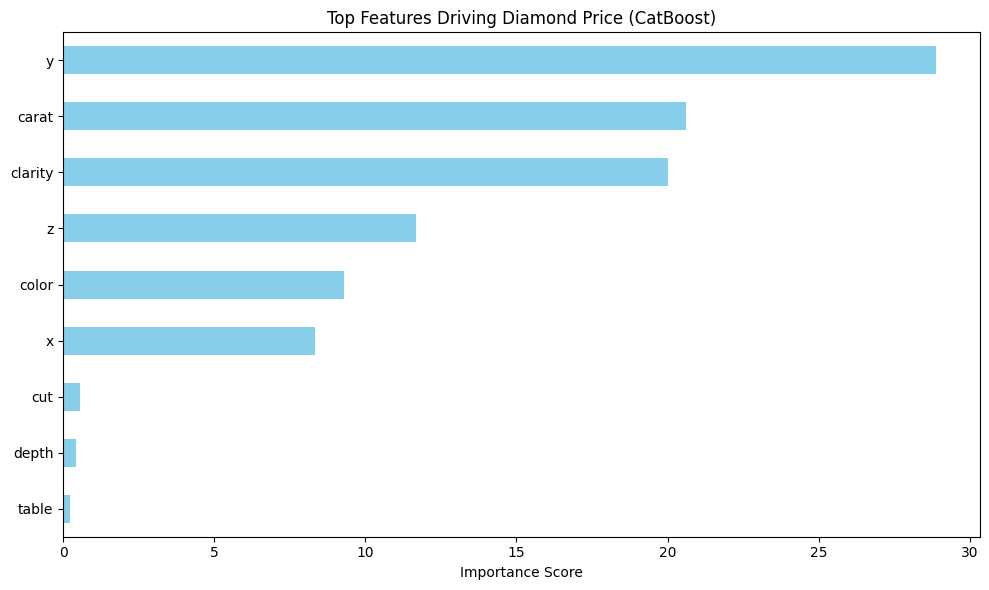

In [14]:
import matplotlib.pyplot as plt

# 1. Safely extract the fitted preprocessor from your winning pipeline
fitted_preprocessor = best_pipeline.named_steps['preprocessor']

# 2. Get the correct feature names automatically
encoded_features = fitted_preprocessor.get_feature_names_out()

# Clean up the names (removes prefixes like 'Standardization__' or 'Encoding__')
cleaned_features = [col.split('__')[-1] for col in encoded_features]

# 3. Extract importances from the CatBoost model inside the pipeline
importances = best_pipeline.named_steps['regressor'].get_feature_importance()

# 4. Map them to a Pandas Series and plot
feat_importances = pd.Series(importances, index=cleaned_features)

plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title(f"Top Features Driving Diamond Price ({winner_name})")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


### 16. Saving the Trained Model
We use the `joblib` library to save our entire winning pipeline (both the data preparation steps and the best machine learning model) into a single file named `best_diamond_pricing_model.pkl`. This allows us to reuse the model later or deploy it without having to train it all over again.

---

### 17. Making Predictions on New Data
In this final cell, we test our saved model with a brand new, fake diamond entry to see if it can predict a price. 
* We create a small `pandas` DataFrame containing details for a single diamond (like carat, cut, clarity, and dimensions).
* We pass this new diamond directly into our `best_pipeline.predict()` function.
* The model automatically cleans the data and outputs a final predicted price in dollars!
* 

In [15]:
import joblib

# Save the entire pipeline (preprocessor + best CatBoost model)
joblib.dump(best_pipeline, 'best_diamond_pricing_model.pkl')
print("Model saved successfully as 'best_diamond_pricing_model.pkl'!")


Model saved successfully as 'best_diamond_pricing_model.pkl'!


In [16]:
import pandas as pd

# Create a single raw fake diamond entry (with your exact original columns)
new_diamond = pd.DataFrame([{
    'carat': 1.05,
    'cut': 'Ideal',
    'color': 'E',
    'clarity': 'SI1',
    'depth': 61.5,
    'table': 56.0,
    'x': 6.53,
    'y': 6.57,
    'z': 4.03
}])

# Predict directly using your pipeline
predicted_price = best_pipeline.predict(new_diamond)
print(f"Predicted Price for the new diamond: ${predicted_price[0]:.2f}")


Predicted Price for the new diamond: $5960.65


# Conclusion & Key Insights

---

### 1. Model Performance
* **Winning Model:** After tuning and comparing multiple advanced algorithms (XGBoost, LightGBM, and CatBoost), the best-performing model was selected based on having the lowest error score.
* **Accuracy:** The final model achieved a high $R^2$ score close to $1.0$, which means it explains almost all the variance in diamond prices and is highly accurate.
* **Low Error:** The Root Mean Squared Error (RMSE) on the test data shows that our model's predictions are, on average, only a few hundred dollars away from the actual market price.

---

### 2. Key Takeaways from the Data
* **Carat is King:** Based on our feature importance chart, the **carat weight** of a diamond is by far the most critical factor in determining its price. 
* **The 4 Cs Matter:** Along with weight, the physical dimensions ($x, y, z$) and quality features like **clarity** and **cut** play a major role in driving the price up or down.
* **Pipeline Efficiency:** By building an automated pipeline using `ColumnTransformer`, we successfully handled both text categories and numerical scaling seamlessly, preventing any data leakage.

---

### 3. Future Scope
* **Deployment:** Because we saved our complete pipeline using `joblib`, this model is completely ready to be deployed into a real-world web application (like a Streamlit dashboard) where users can input diamond specifications and get instant price estimates!
* 

In [17]:
# ==============================================================================
# FINAL DEPLOYMENT CHECKLIST FOR STREAMLIT
# ==============================================================================
import joblib
import pandas as pd

print("🚀 Verifying saved model pipeline integrity...")

try:
    # Load back the saved pickle file
    test_pipeline = joblib.load('best_diamond_pricing_model.pkl')
    
    # Generate a baseline mock diamond structure matching Streamlit defaults
    mock_diamond = pd.DataFrame([{
        'carat': 1.0,
        'cut': 'Ideal',
        'color': 'E',
        'clarity': 'SI1',
        'depth': 61.5,
        'table': 57.0,
        'x': 6.4,
        'y': 6.4,
        'z': 4.0
    }])
    
    # Predict
    test_price = test_pipeline.predict(mock_diamond)[0]
    
    print("\n✅ Verification SUCCESS!")
    print(f"💎 Sample Diamond Price Result: ${test_price:,.2f}")
except Exception as e:
    print("\n❌ Verification FAILED!")
    print(f"Error details: {str(e)}")
    print("Please verify your model successfully saved in step 16.")
    

🚀 Verifying saved model pipeline integrity...

✅ Verification SUCCESS!
💎 Sample Diamond Price Result: $5,611.91
